In [1]:
#Importing  all required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler

In [2]:
# Loading given traffic dataset

df = pd.read_csv(r"C:\Users\G_P_S\anaconda3\envs\projects\Uber_Mentornship\Dataset_Uber Traffic.csv")

In [3]:
# Inspecting the given dataset
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


,DateTime,Junction,Vehicles,ID
0,01/11/15 0:00,1,15,20151101001
1,01/11/15 1:00,1,13,20151101011
2,01/11/15 2:00,1,10,20151101021
3,01/11/15 3:00,1,7,20151101031
4,01/11/15 4:00,1,9,20151101041


In [4]:
# Convert DateTime to datetime object
df['DateTime'] = pd.to_datetime(df['DateTime'])

In [5]:
# Handling missing values & replacing duplicates into the givcen dataset
df = df.dropna()
df = df.drop_duplicates()


In [8]:
# Aggregating traffic data into hourly intervals for each junction
df_hourly = df.set_index('DateTime').groupby(['Junction', pd.Grouper(freq='H')])['Vehicles'].sum().reset_index()

#Preprocess the data: Normalize or standardize the data to facilitate comparison across different time periods and junctions.( Feature Scaling)

scaler = StandardScaler()
df_hourly['Vehicles_normalized'] = scaler.fit_transform(df_hourly[['Vehicles']])
print(df_hourly.head())

   Junction            DateTime  Vehicles  Vehicles_normalized
0         1 2015-01-11 00:00:00        15            -0.375489
1         1 2015-01-11 01:00:00        13            -0.471875
2         1 2015-01-11 02:00:00        10            -0.616454
3         1 2015-01-11 03:00:00         7            -0.761034
4         1 2015-01-11 04:00:00         9            -0.664648


Index(['DateTime', 'Junction', 'Vehicles', 'ID'], dtype='object')


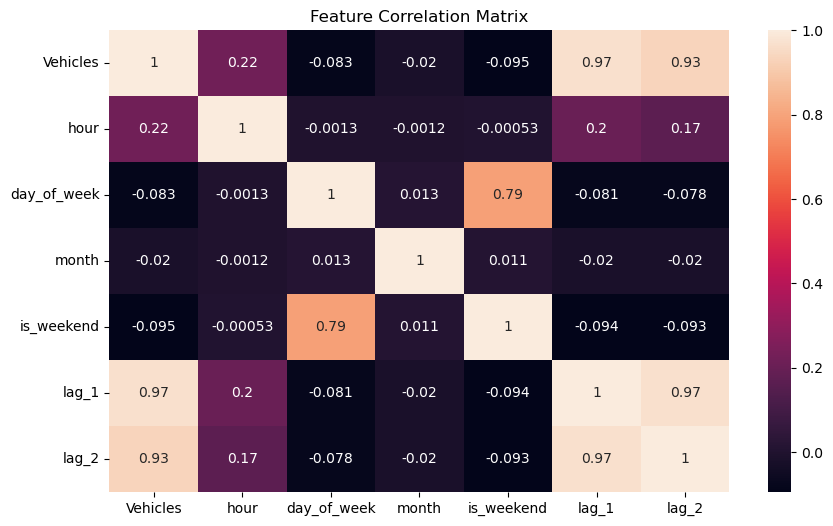

In [56]:
from sklearn.ensemble import RandomForestRegressor
# Create new features
df_hourly['hour'] = df_hourly['DateTime'].dt.hour
df_hourly['day_of_week'] = df_hourly['DateTime'].dt.dayofweek
df_hourly['month'] = df_hourly['DateTime'].dt.month
df_hourly['is_weekend'] = df_hourly['day_of_week'].isin([5, 6]).astype(int)

# Develop lag features
df_hourly = df_hourly.sort_values(['Junction', 'DateTime'])
df_hourly['lag_1'] = df_hourly.groupby('Junction')['Vehicles_normalized'].shift(1)
df_hourly['lag_2'] = df_hourly.groupby('Junction')['Vehicles_normalized'].shift(2)


print(df.columns)

# Drop rows with NaN values from lag features
df_hourly.dropna(subset=['lag_1', 'lag_2'], inplace=True)



# Correlation analysis
plt.figure(figsize=(10, 6))
sns.heatmap(df_hourly[['Vehicles', 'hour', 'day_of_week', 'month', 'is_weekend', 'lag_1', 'lag_2']].corr(), annot=True)
plt.title("Feature Correlation Matrix")
plt.show()


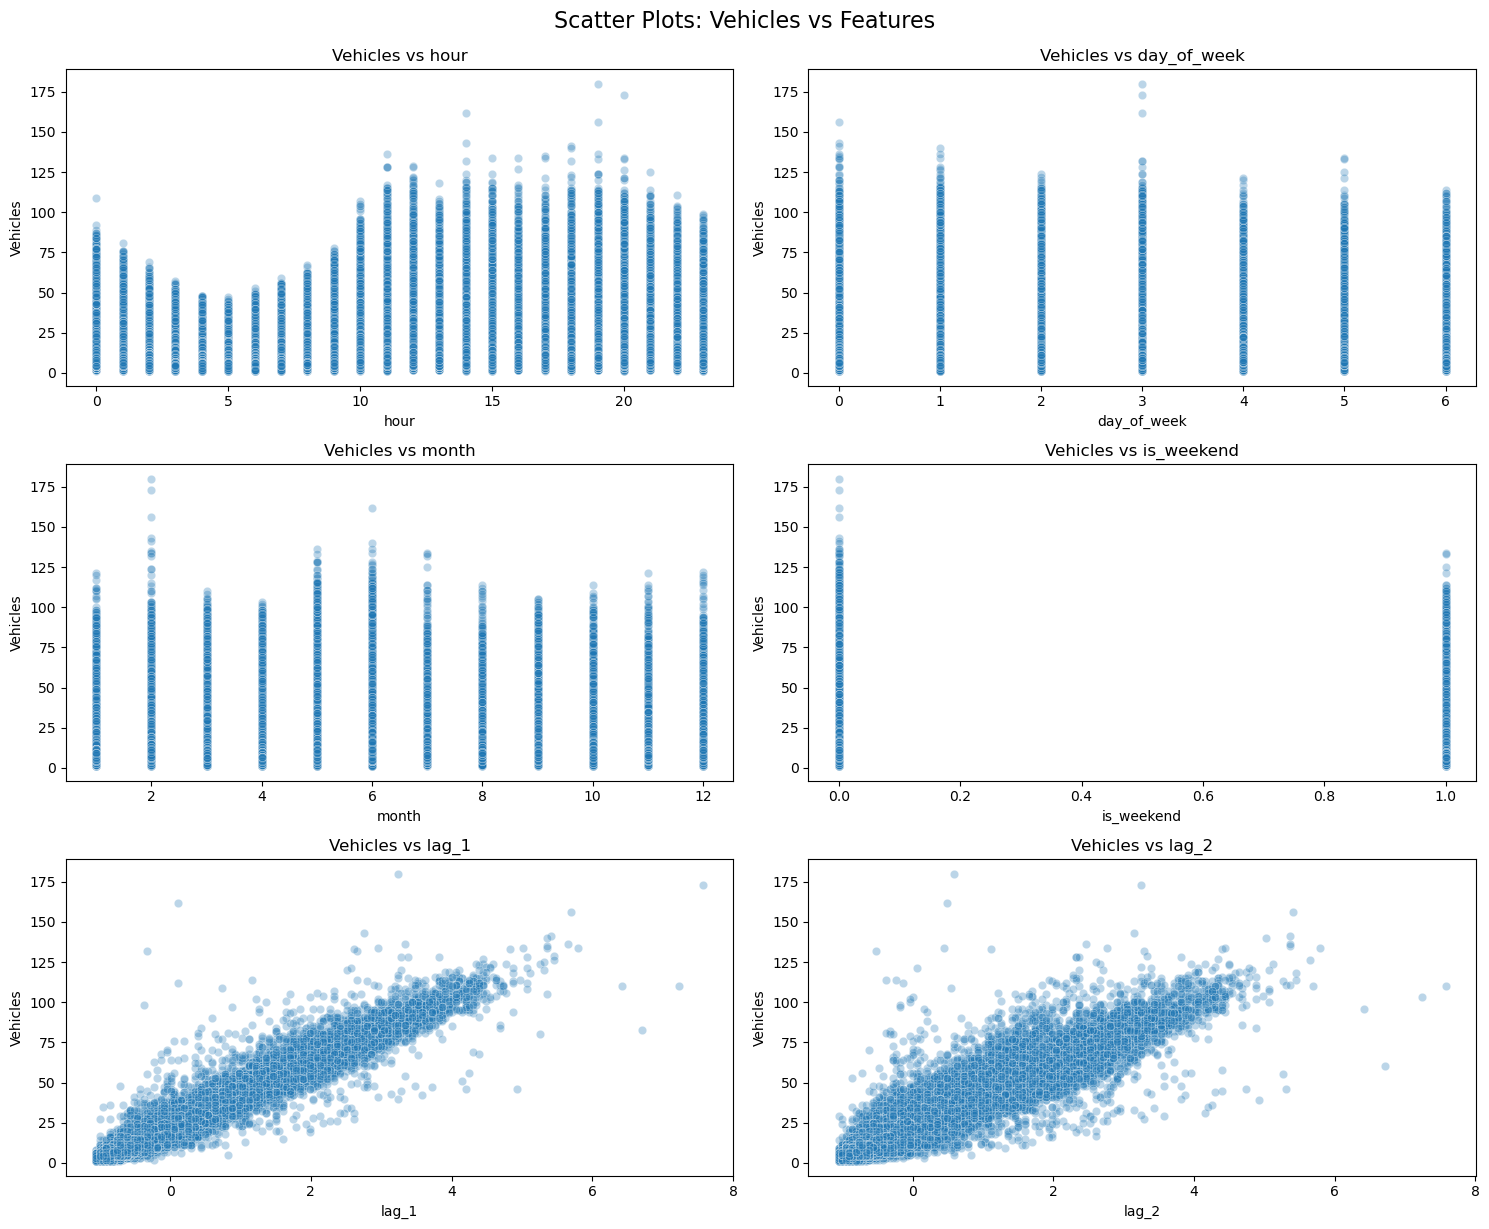

In [64]:
# Set up the overall figure size: width=15 inches, height=12 inches
plt.figure(figsize=(15, 12))

# Loop over each feature to create a 3×2 grid of subplots
for i, feature in enumerate(features):
    plt.subplot(3, 2, i + 1)                                                    # Define the subplot i.e., 3 rows, 2 columns, index i+1

    # Plot a scatter plot of the x- feature vs. y- Vehicles where alpha=0.3 adds transparency to reduce overplotting
    sns.scatterplot(x=df_hourly[feature], y=df_hourly['Vehicles'], alpha=0.3) 
    plt.title(f'Vehicles vs {feature}')
    # Labeling the x-axis as feature
    plt.xlabel(feature)
    # Labeling the y-axis as Vehicles 
    plt.ylabel('Vehicles')
# Adjust spacing
plt.tight_layout()
plt.suptitle('Scatter Plots: Vehicles vs Features', fontsize=16, y=1.02)
#showing / generating the plot
plt.show()

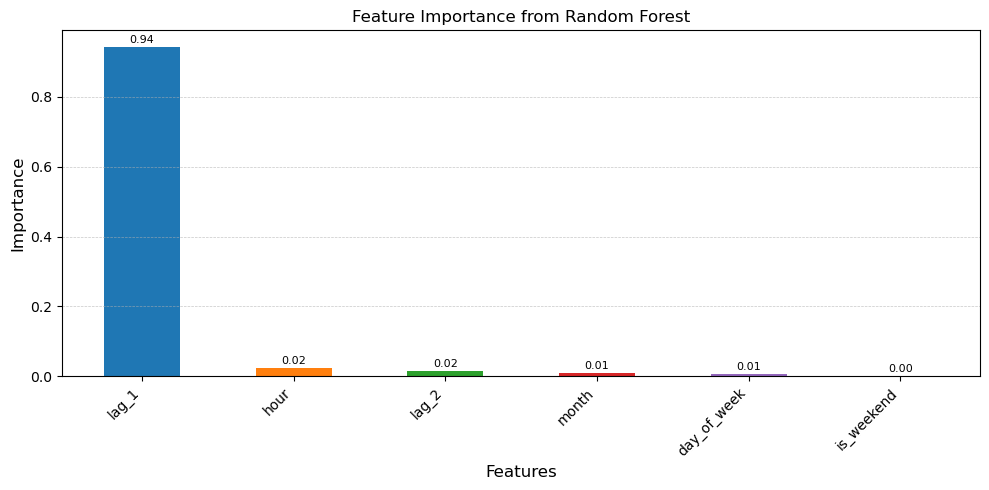

In [52]:
# Evaluate feature importance
features = ['hour', 'day_of_week', 'month', 'is_weekend', 'lag_1', 'lag_2']
X = df_hourly[features]
y = df_hourly['Vehicles_normalized']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
#importance.plot(kind='bar', title='Feature Importance from Random Forest')
#plt.show()
# Define custom colors for each bar
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']  
bar_colors = [colors[i % len(colors)] for i in range(len(importance))]

# Plot importance with different colors and annotations
plt.figure(figsize=(10, 5))
bars = plt.bar(importance.index, importance.values, color=bar_colors, width=0.5)
plt.title("Feature Importance from Random Forest")
plt.xlabel("Features", fontsize = 12)
plt.ylabel("Importance", fontsize = 12)
plt.xticks(rotation=45, ha='right')

# Add horizontal gridlines on y-axis
plt.gca().yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Annotate bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005, f"{height:.2f}", 
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()